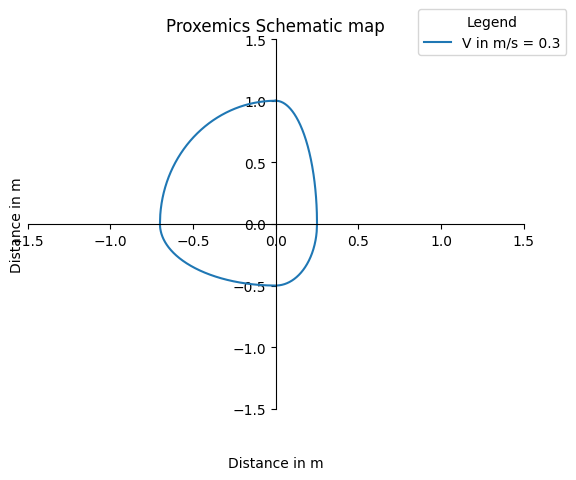

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
    [0.3, 0.25, -0.7, 1, -0.5]
])

# Tested Vector, Right x, Left x, Forward y, Backward y
plt.figure()
res = 0.001

for i in range(data.shape[0]):
    z = data[i, 0]
    xp = data[i, 1]
    xn = data[i, 2]
    yp = data[i, 3]
    yn = data[i, 4]

    X = []
    Y = []

    x = np.arange(0, xp + res, res)
    y = np.sqrt(np.maximum(0, (1 - (x**2 / xp**2)) * yp**2))
    X = np.concatenate([X, x])
    Y = np.concatenate([Y, y])

    x = np.arange(xp, 0 - res, -res)
    y = -np.sqrt(np.maximum(0, (1 - (x**2 / xp**2)) * yn**2))
    X = np.concatenate([X, x])
    Y = np.concatenate([Y, y])

    x = np.arange(0, xn - res, -res)
    y = -np.sqrt(np.maximum(0, (1 - (x**2 / xn**2)) * yn**2))
    X = np.concatenate([X, x])
    Y = np.concatenate([Y, y])

    x = np.arange(xn, 0 + res, res)
    y = np.sqrt(np.maximum(0, (1 - (x**2 / xn**2)) * yp**2))
    X = np.concatenate([X, x])
    Y = np.concatenate([Y, y])

    plt.plot(X, Y, label=f'V in m/s = {z}')

    plt.title('Proxemics Schematic map')
    plt.xlabel('Distance in m')
    plt.ylabel('Distance in m')
    plt.xlim([-1.5, 1.5])
    plt.ylim([-1.5, 1.5])

    ax = plt.gca()
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.labelpad = 150
    ax.yaxis.labelpad = 150

plt.legend(title='Legend', bbox_to_anchor=(1.1, 1.1), loc='upper right')

plt.show()

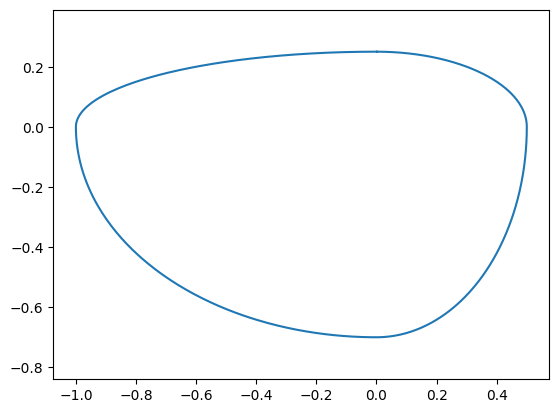

In [23]:

def proxemics_boundary(aR, aL, bF, bB, x0, y0, psi, n=720):
    th = np.linspace(0, 2*np.pi, n, endpoint=False)
    a = np.where(np.cos(th) >= 0, aR, aL)
    b = np.where(np.sin(th) >= 0, bF, bB)
    r = 1.0 / np.sqrt((np.cos(th)**2)/(a**2) + (np.sin(th)**2)/(b**2))
    xl, yl = r*np.cos(th), r*np.sin(th)                # local
    c, s = np.cos(psi), np.sin(psi)
    x = x0 + c*xl - s*yl                               # world
    y = y0 + s*xl + c*yl
    return x, y

def proxemics_contains(aR, aL, bF, bB, x0, y0, psi, x, y):
    # world -> local
    dx, dy = x - x0, y - y0
    c, s = np.cos(psi), np.sin(psi)
    xl, yl =  c*dx + s*dy, -s*dx + c*dy
    a = np.where(xl >= 0, aR, aL)
    b = np.where(yl >= 0, bF, bB)
    return (xl/a)**2 + (yl/b)**2 <= 1.0

# example: one person at (0,0) facing +y
aR, aL, bF, bB = 0.25, 0.70, 1.00, 0.50
x, y = proxemics_boundary(aR, aL, bF, bB, x0=0.0, y0=0.0, psi=np.pi/2)
plt.plot(x, y); plt.axis('equal'); plt.show()